# Welcome to lkdata!

lkdata is designed to handle 1D, 2D, and 3D transformations using the built-in power of pandas. lkdata serves at the backend for lightkurve v3. lightkurve users will typically not interact with lkdata directly. However, they are used for the affiliated packages lktimeseries and lkcubes to process Lightcurve (LC), Target Pixel File (TPF), and Full Frame Image (FFI) data for the TESS and Kepler/K2 missions. 

In this notbook, we will cover the basic properties of lkdata, as well as examples of how to use the built-in functionality. 

lkdata has three main classes to deal with data of different shapes and properties.
- Timeseries (such as LC) data is handled by DataSeries, BoolSeries, or BitwiseSeries depending on the data type (more on that in section 1 below)
- 3-dimensional data (such as TPF or FFI time series) are handled by DataCube
- Collections of timeseries-like arrays with shared times can be handled by DataFrame. 

All of these data products require at a minimum some sort of temporal data (time, cadence number, etc) and data (and optional errors) associated with those times. When performing math operations on the data, such as adding, subtracting, or multiplying, these associated errors are handled appropriately (eg, errors are automatically added in quadrature when appropriate). 

A mixture of any of these types of data can be bundled in a single DataSet, provided they all have the same times associated with them. The advantage of the DataSet is that operations applied to the DataSet, such as binning or slicing, are applied to all associated Series, Frame, and Cube objects as appropriate. For example, you could bundle a group of DataSeries that each represent a single source of flux (simple aperture flux, corrected flux, background flux, etc) and simulataneously cutout a time range of interest. We will see more applications for DataCubes in the examples below. 

In [1]:
# Import all of the packages we will use throughout this notebook
import sys
import os
parent_dir_name = os.path.dirname(os.path.dirname(os.path.dirname(os.path.realpath('lkdata'))))
sys.path.append(parent_dir_name + "/src")
import lkdata
import lksearch
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt



# 1 - Handling Timeseries-like data

Data arrays that are associated with time steps can be represented by one of three different classes: DataSeries, BoolSeries, or BitwiseSeries. DataSeries represent any numerical data that varies with time, such as flux, energy, or other lightcurve-like data. BoolSeries handle any Boolean data that varies by time, such as a Boolean mask for time steps that are 'good' or 'bad'. Finally, BitwiseSeries handle data that represents bitwise information. This was motivated by the TESS, Kepler, and K2 quality masks, which use bitwise AND operations to represent different combinations of data quality flags (Look [here](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview#id-2.0-DataProductOverview-Table:CadenceQualityFlags) for more details). 

The DataSeries structure allows us to manipulate this data in a number of ways, including binning by time, slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section */SOME SECTION/* below. 


### 1.1 DataSeries

In [2]:
# Generate some random times. 
times = np.linspace(0, 24, 120)

# Generate some random data
data = np.random.randn(len(times))

# Generate some errors
data_err = np.abs(data) * .1

All lkdata products require at a minimum some sort of data and an associated time. Multiple time indices are allowed, but only a single data product is allowed. Associated uncertainties are optional. You can bundle multiple objects together using a DataSet. For more information on budling, see section 5 below. 

In [12]:
# TODO: can you give 'data' a keyword so there is a column label? Index='string' looks like it should work in the docs, but doesn't

series = lkdata.DataSeries(data=data,#{'data':data},
                       uncertainty=data_err,
                       time_indices={'time':times},
                    #index=times
                          )
series

time_index  time     
0           0.000000     1.309976
1           0.201681     0.480582
2           0.403361     0.700204
3           0.605042     1.415732
4           0.806723    -1.201307
                           ...   
115         23.193277   -0.184867
116         23.394958    1.845865
117         23.596639   -1.629008
118         23.798319   -0.128920
119         24.000000   -0.494825
Length: 120, dtype: float64


📉 DataSeries (120,)

Great, we've initialized our first DataSeries! The representation of the object is very similar to a pandas DataFrame. The above cell shows that this is a DataSeries object with a length of 120. All time columns are included as a [MultiIndex](https://pandas.pydata.org/docs/user_guide/advanced.html). The uncertainties are not shown in the default [repr](https://docs.python.org/3/library/functions.html#repr), but you can see they are there using describe_series(), as shown below.

In [6]:
series.describe_series()

📉 DataSeries (120,) (120,) (ntime)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120,))

Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]


In [7]:
series.time

array([ 0.        ,  0.20168067,  0.40336134,  0.60504202,  0.80672269,
        1.00840336,  1.21008403,  1.41176471,  1.61344538,  1.81512605,
        2.01680672,  2.21848739,  2.42016807,  2.62184874,  2.82352941,
        3.02521008,  3.22689076,  3.42857143,  3.6302521 ,  3.83193277,
        4.03361345,  4.23529412,  4.43697479,  4.63865546,  4.84033613,
        5.04201681,  5.24369748,  5.44537815,  5.64705882,  5.8487395 ,
        6.05042017,  6.25210084,  6.45378151,  6.65546218,  6.85714286,
        7.05882353,  7.2605042 ,  7.46218487,  7.66386555,  7.86554622,
        8.06722689,  8.26890756,  8.47058824,  8.67226891,  8.87394958,
        9.07563025,  9.27731092,  9.4789916 ,  9.68067227,  9.88235294,
       10.08403361, 10.28571429, 10.48739496, 10.68907563, 10.8907563 ,
       11.09243697, 11.29411765, 11.49579832, 11.69747899, 11.89915966,
       12.10084034, 12.30252101, 12.50420168, 12.70588235, 12.90756303,
       13.1092437 , 13.31092437, 13.51260504, 13.71428571, 13.91

### 1.2 BoolSeries

Creating a BoolSeries is very similar to creating a DataSeries. The main difference is that the data is now a boolean array. We will create one my making a boolean array based on the random data generated in Section 1.1.

In [8]:
# Create a boolean array
mask = data > 0
mask

array([ True,  True,  True,  True, False, False, False,  True,  True,
        True,  True, False, False,  True,  True, False,  True, False,
       False, False,  True,  True,  True, False,  True, False, False,
        True, False, False,  True,  True, False, False,  True, False,
       False,  True,  True, False,  True,  True, False, False,  True,
        True,  True, False,  True, False, False,  True, False, False,
        True, False,  True, False,  True,  True, False,  True, False,
       False,  True, False, False, False, False, False,  True, False,
        True,  True,  True,  True, False,  True,  True, False, False,
       False,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True, False, False, False,  True, False, False,
        True,  True, False,  True,  True,  True, False, False, False,
       False, False, False, False, False,  True,  True, False,  True,
       False, False, False])

In [9]:
# TODO: Boolseries allow errors. Should they?

boolseries = lkdata.BoolSeries(data=mask,
                        uncertainty = data_err,
                       time_indices={'time':times},
                          )
boolseries.describe_series()

⚫️⚪️ BoolSeries (120,) (120,) (ntime)


Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

User defined attributes accessible via `object.key`
(displaying only unique values)
	uncertainty :	[0.13099763 0.04805819 ... 0.01289203 0.04948254]


In [10]:
boolseries.uncertainty

array([1.30997629e-01, 4.80581859e-02, 7.00204242e-02, 1.41573243e-01,
       1.20130743e-01, 3.21629697e-02, 6.86687480e-02, 2.25247953e-03,
       6.97788738e-02, 1.16684719e-02, 1.51684505e-02, 8.47056918e-02,
       1.97000727e-02, 7.00422131e-02, 2.63464470e-02, 1.07718121e-01,
       1.45795874e-01, 1.71185658e-02, 3.43350906e-02, 1.56283841e-02,
       6.25453839e-02, 1.13941834e-01, 9.93360375e-02, 1.46943668e-01,
       4.02742898e-02, 1.93737764e-01, 4.64839121e-02, 4.99676294e-02,
       6.09100897e-02, 7.27341824e-03, 1.59593552e-01, 5.80549703e-02,
       1.03855088e-02, 1.22697598e-02, 1.33716725e-01, 1.93413099e-01,
       2.38150282e-01, 4.80249287e-03, 1.45459146e-01, 4.69332557e-02,
       6.43844955e-02, 6.90888078e-02, 4.35964280e-02, 4.47150459e-03,
       8.52355391e-02, 3.68625828e-03, 5.43479109e-02, 2.29192095e-01,
       1.57285205e-01, 1.16473349e-02, 7.98679459e-02, 2.58045578e-02,
       1.54154347e-04, 1.08606393e-01, 1.21069927e-01, 4.68741133e-02,
      

### 1.3 Manipulating DataSeries data

Once you have a time series, you can manipulate the time series in various ways. Common actions you make might be slicing the data or binning the data. 

In the cell below, we demonstrate time binning. In lkdata, this is known as downsampling. By default, this combined 5 time steps. However, you can choose other time steps by specifying nframes=X. Currently, lkdata only allows for summing the data within time bins (with errors added in quadrature). 

TODO: Allow for other combination methods (mean and median)
TODO: Does it allow for a sliding window?

In [13]:
# TODO - how does downsampling work for data series? I have mostly been working with DataCubes
# TODO - Dig in to how level works and the time steps (can only specify n_bins)
downsampled_series = series.downsample(level='time') # default 5 time steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (120,)
The downsampled series has shape (24,)
mid_index  indices                time     
2.0        [0 1 2 3 4]            0.403361     2.705187
7.0        [5 6 7 8 9]            1.411765    -0.171319
12.0       [10 11 12 13 14]       2.420168     0.071513
17.0       [15 16 17 18 19]       3.428571    -0.290043
22.0       [20 21 22 23 24]       4.436975     1.691539
                                                 ...   
97.0       [95 96 97 98 99]       19.563025    2.224892
102.0      [100 101 102 103 104]  20.571429    0.550225
107.0      [105 106 107 108 109]  21.579832   -2.157995
112.0      [110 111 112 113 114]  22.588235   -2.058943
117.0      [115 116 117 118 119]  23.596639   -0.591756
Length: 24, dtype: float64


📉 DataSeries (24,)

In [14]:
downsampled_series = series.downsample(level='time_index') # default 5 time steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (120,)
The downsampled series has shape (24,)
mid_index  indices                time     
2.0        [0 1 2 3 4]            0.403361     2.705187
7.0        [5 6 7 8 9]            1.411765    -0.171319
12.0       [10 11 12 13 14]       2.420168     0.071513
17.0       [15 16 17 18 19]       3.428571    -0.290043
22.0       [20 21 22 23 24]       4.436975     1.691539
                                                 ...   
97.0       [95 96 97 98 99]       19.563025    2.224892
102.0      [100 101 102 103 104]  20.571429    0.550225
107.0      [105 106 107 108 109]  21.579832   -2.157995
112.0      [110 111 112 113 114]  22.588235   -2.058943
117.0      [115 116 117 118 119]  23.596639   -0.591756
Length: 24, dtype: float64


📉 DataSeries (24,)

You are also able to easily slice the data. You can slice in the same manner you slice numpy arrays. In the example below we slice every other sample from the first 100 time steps in the DataSeries.

In [15]:
sliced_series = series[:100:2]
print(f"The series has shape {series.shape}")
print(f"The series after slicing has shape {sliced_series.shape}")
sliced_series

The series has shape (120,)
The series after slicing has shape (50,)
time_index  time     
0           0.000000     1.309976
2           0.403361     0.700204
4           0.806723    -1.201307
6           1.210084    -0.686687
8           1.613445     0.697789
                           ...   
90          18.151261    0.215590
92          18.554622    0.077373
94          18.957983   -0.587709
96          19.361345    0.961555
98          19.764706   -0.276525
Length: 50, dtype: float64


📉 DataSeries (50,)

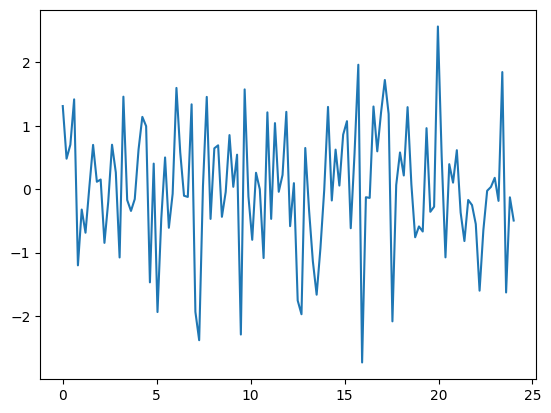

In [16]:
# TODO: is there an easy way to access the time?
plt.plot(series.time, series.data)

## 2 - Handling 2D data

2D data (images) are single frames of data (ie, data from a single time stamp). lkdata uses the DataFrame class for these products. In this section we will learn the basics of the DataFrame class as well as how to manipulate them.

## 2 - Handling Cube-like data

Now let's take a look at 3 dimensional data. lkdata handles this type of data with the DataCube class. For TESS, Kepler, and K2 data, this would be the data structure used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section */SOME SECTION/* below. 

One important thing to keep in mind with all lkdata structures is that they are designed to handle various types of time series data. This means that all products must be tied to at least one time array. We will see how this is important throughout this notebook.

### 2.1 creating a DataCube

In [17]:
# Generate some random times. 
times = np.linspace(0, 24, 120)


In [18]:
# Generate some random data
data = np.random.randn(len(times), 5,7)

# Generate some errors
data_err = np.abs(data) * .1



In [19]:
# print out the first 
times[:10], data[:10], data_err[:10]

(array([0.        , 0.20168067, 0.40336134, 0.60504202, 0.80672269,
        1.00840336, 1.21008403, 1.41176471, 1.61344538, 1.81512605]),
 array([[[ 0.3025305 ,  2.34610871, -0.69472385, -0.29580446,
          -0.24603606,  0.86880292, -0.39052404],
         [-2.56530942,  1.22339814,  0.59159662,  1.11324772,
           0.95870208,  1.04207801, -0.727906  ],
         [-0.02641171, -1.4878719 , -0.10001677, -1.02906246,
           0.01748549,  1.54121197,  1.20974369],
         [ 0.53825908,  0.31567327,  0.62026592, -0.56748898,
          -0.17677926, -0.16469404, -0.62458878],
         [-0.26269485,  0.10457639, -0.67690249,  1.20261437,
           2.39142353, -0.24274073,  1.08034857]],
 
        [[ 0.22231042,  1.03225532,  0.11089505,  0.18456366,
           0.47506101, -0.1418938 ,  0.03873891],
         [ 0.52390574,  0.71604684,  0.76286696,  0.26364608,
           0.13986407, -0.88828725, -1.91520338],
         [ 0.33969135, -2.30624641, -0.53410606, -0.26149268,
          -0.

In [20]:
print(times.shape, data.shape, data_err.shape)

(120,) (120, 5, 7) (120, 5, 7)


We have now generated the data needed to make a DataCube. In this example, we are making a timeseries with 120 time steps. We also have a 2-dimentional data product for each of these times steps. We can now put this information into our DataCube object. 

In [21]:
cube = lkdata.DataCube(data=data,
                       uncertainty=data_err,
                       time_indices={'time':times})

In [22]:
cube

📘 DataCube (120, 5, 7), Uncertainty: True

Great! You can see that when we call the cube object, we get a summary of the contents. This tells us the shape of the cube and whether there are uncertainties associated with the data. It also shows a visualization of the data contained in the first time step.

We can get more information about the data contained in the Cube by calling describe_cube()

In [23]:
cube.describe_cube()

📘 DataCube (120, 5, 7), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (120, 35)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 5, 7))

Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Number of unique 'series': 35

Row names: ['row']
	row         :	[0 0 ... 4 4]

Column names: ['col']
	col         :	[0 1 ... 5 6]

User defined attributes accessible via `object.key`
(displaying only unique values)


### 2.2 Slicing a DataCube

Now that we have our DataCube set up, we can start manipulating the data. For example, what if we want only 1 out of every 10 time steps?

In [24]:
sub_cube = cube[::10, :,:] # Slice in the time step dimension
sub_cube

📘 DataCube (12, 5, 7), Uncertainty: True

In [25]:
sub_cube = cube[:, 1:4,2:5] # Cut out a selection of pixels
sub_cube

📘 DataCube (120, 3, 3), Uncertainty: True

This looks great when slicing contiguous pixels. What happens when you extract non-contiguous pixels?

In [26]:
sub_cube = cube[::2, ::2,::2] # Cut out a selection of pixels
sub_cube

,series,0,2,4,6,14,16,18,20,28,30,32,34
,row,0,0,0,0,2,2,2,2,4,4,4,4
,col,0,2,4,6,0,2,4,6,0,2,4,6
time_index,time,,,,,,,,,,,,
0,0.000000,0.302531,-0.694724,-0.246036,-0.390524,-0.026412,-0.100017,0.017485,1.209744,-0.262695,-0.676902,2.391424,1.080349
2,0.403361,-1.614811,0.076556,-0.587769,-1.692073,2.427048,1.861970,-1.466856,-0.187451,1.086243,-1.163808,-0.499683,0.341387
4,0.806723,-0.083486,0.671926,-1.150496,-0.611095,-0.207220,0.879417,0.493397,0.598299,-0.278400,1.280615,-0.807655,0.687593
6,1.210084,-1.764442,1.654595,0.443485,-0.092863,-1.056438,0.168654,-0.841614,1.736133,-0.023991,-1.412740,-0.617499,-0.936546
8,1.613445,0.388819,0.245535,-1.806372,-0.357733,-0.080596,-0.224329,-0.566005,0.251514,0.633835,1.176527,0.216970,-0.554170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,22.184874,1.345788,0.138544,-0.168589,-0.573468,-0.104602,0.148243,-0.570778,-0.910291,0.594783,1.207444,0.058087,0.694041


This looks a little bit different. Since we no longer have contiguous blocks of pixels, this now returns the underlying pandas data frame contianing information on each pixel. Note that in this case you can no longer treat the object as a DataCube with the same functionality as before. Instead the data is handled by the third class, a DataFrame. Essentially, this is a collection of individual light curves that we want to treat as a cohesive unit. 

You are also able to generate your own DataFrames, as shown in the cell below. 



In [27]:
# Generate some random data for 10 'timeseries' with 120 time steps
data = np.random.randn(120,10)

# Generate some errors
data_err = np.abs(data) * .1

frame = lkdata.DataFrame(data=data,
                       uncertainty=data_err,
                          )

# TODO: DataFrame repr should also say if there are associated errors. 

frame

series,0,1,2,3,4,5,6,7,8,9
time_index,,,,,,,,,,
0,0.813748,1.612290,-0.726121,-1.234803,-0.129097,0.468976,1.553254,-1.253861,2.556047,1.367727
1,0.331644,0.626776,1.314780,0.076878,-0.971147,0.723980,-0.065697,-0.662664,0.053940,-0.316923
2,0.289569,0.519655,-0.537926,-0.729125,-0.855241,-1.512872,-1.285752,0.672145,-0.180728,-1.042876
3,-1.457778,-0.852163,1.018298,0.531907,-0.339388,-1.728100,1.772409,-1.196787,-0.847353,0.726688
4,-1.011287,-0.650742,0.440769,-0.553988,-2.074527,1.732311,-1.404616,-1.102674,-0.879466,1.775415
...,...,...,...,...,...,...,...,...,...,...
115,-0.403019,-0.108272,-1.193191,-1.703496,0.984598,-0.827377,0.484817,-1.997246,-1.097293,0.213042
116,1.689201,-1.812038,-0.373941,-0.634019,0.264850,-1.272795,0.209409,-1.603245,0.029584,-0.173449
117,-0.193238,0.531194,-1.075532,-0.145814,-1.208583,-0.522163,-1.212235,1.275093,0.589799,1.440554


Finally, what happens when when you are interested in a single time step?

In [28]:
cube[0,:,:]

📘 DataCube (1, 5, 7), Uncertainty: True

### 2.3 Downsampling (binning)

Instead of slicing, we may instead want to bin the data in the time dimension. This has the effect of taking the *sum* of each 'pixel' over the specified number of time steps. Note that the uncertaintaies are automatically added in quadrature. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [29]:
timebin_cube = cube.downsample(nframes=2, level="time")
timebin_cube

📘 DataCube (60, 5, 7), Uncertainty: True

You are also allowed to spatially downsample the object. This would create the *sum* of pixels. If you specify "factor={integer}", it will use the same downsample size for column and row. For unevenly sized bins, you are able to sepcify col_factor/row_factor. Column/rows at the edge that do not "fill up" a new bin are discarded. In the case below, this would mean that column 6 and row 4 are discarded in the resulting DataCube object. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [25]:
spacebin_cube = cube.spatial_downsample(factor=2)
spacebin_cube

📘 DataCube (120, 2, 3), Uncertainty: True

In [26]:
spacebin_cube = cube.spatial_downsample(col_factor=3, row_factor=2)
spacebin_cube

📘 DataCube (120, 2, 2), Uncertainty: True

### 2.4 Other Cube Properties

lkdata objects inherit a lot of functionality from pandas objects. For example, you can call mean/median/min/max functions specifying the axis as you would a pandas dataframe. 

Notice in the case below, you get a tuple as a result. The first array returns the max data value for each pixel over the time dimension, while the second array shows the max uncertainty for each pixel over the time dimension. 

In [27]:
cube.max(axis=0)

(array([[2.02482413, 2.97373175, 3.51405721, 2.76153535, 2.8637301 ,
         2.80634606, 2.34310209],
        [2.81169908, 2.21376287, 2.74646121, 2.80151301, 2.24063218,
         2.33218404, 2.11607299],
        [2.28528634, 2.38137111, 3.15964508, 2.87549811, 2.80919164,
         2.5917208 , 2.29312425],
        [2.12892144, 2.62517553, 2.41829816, 2.34429852, 2.82429659,
         2.67760496, 2.55098153],
        [3.01044558, 2.40671292, 2.18359285, 1.92508561, 2.28895196,
         2.74215052, 1.72893544]]),
 array([[0.24134124, 0.30104456, 0.29737318, 0.28754981, 0.27615353,
         0.22043272, 0.23813711],
        [0.24079476, 0.19962406, 0.23442985, 0.25501154, 0.22489891,
         0.22406322, 0.26493066],
        [0.2612555 , 0.28637301, 0.27421505, 0.26251755, 0.28116991,
         0.31596451, 0.28242966],
        [0.2801513 , 0.20779491, 0.22601888, 0.26928251, 0.24182982,
         0.24942071, 0.23431021],
        [0.19282073, 0.28091916, 0.22852863, 0.27464612, 0.35140572,
  

In [28]:
cube.min(axis=1)

📉 DataSeries (120,)
time_index  time     
0           0.000000    -2.721609
1           0.201681    -2.044951
2           0.403361    -2.106837
3           0.605042    -4.402876
4           0.806723    -1.739393
                           ...   
115         23.193277   -2.240162
116         23.394958   -1.457920
117         23.596639   -2.106178
118         23.798319   -2.001804
119         24.000000   -1.766781
Length: 120, dtype: float64

In [29]:
TODO: Any other features we should introduce?

Object `introduce` not found.


# 3 - Example with real TESS data

For TESS, Kepler, and K2 data, the DataCube could hold the data used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we get any further, let's get some data we can use to motivate the different functionality. K2-18 b is a Hycean planet originally found by the K2 mission. Subsequently, this planet has been observed by TESS. Let's download a TPF cutout from the FFI using TESScut.

In [30]:
# Search for data we will use to populate our DataCube
results = lksearch.TESSSearch('K2-18', exptime=600).cubedata
results

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,388804061,TESS-SPOC,HLSP,45,600.0,0.0,2021,FITS
1,388804061,TESS-SPOC,HLSP,46,600.0,0.0,2021,FITS
2,"172.56049060233, 7.58840426347",TESScut,TESS Sector 45,45,600.0,0.0,2021,TESS FFI Cutout (sector 45)
3,"172.56049060233, 7.58840426347",TESScut,TESS Sector 46,46,600.0,0.0,2021,TESS FFI Cutout (sector 46)
4,"172.56049060233, 7.58840426347",TESScut,TESS Sector 72,72,200.0,0.0,2023,TESS FFI Cutout (sector 72)


In [31]:
# Download one of the data products. Let's cut out a TPF from sector 45. 
# I will cut out pixels of an uneven size to make the later transformations more clear
manifest = results[2].download(TESScut_size=(11,9))
manifest

,Local Path,Status
0,/Users/nthom/.lksearch/cache/mastDownload/TESS...,COMPLETE


In [32]:
# Read in our downloaded file using astropy's fits functionality
lcf = fits.open(manifest['Local Path'][0])
lcf

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1689d20d0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x1689da400>, <astropy.io.fits.hdu.image.ImageHDU object at 0x1689daac0>]

A DataCube product requires a minimum of two components: a 1-d array containing the time and a 3D array with shape (ntime, nrow, ncol).

We will start by making a simple DataCube object that just contains the time, flux, and flux error information. Note that more additional time series information, such as the time correction applied to the data, can also be store in the Cube.  

In [33]:
time = lcf[1].data['TIME']
timecorr = lcf[1].data['TIMECORR'] #light arrival time correction applied
flux = lcf[1].data['FLUX']#.transpose([0,2,1]) # a TPF has a shape (ntimes, ncol, nrow), so we need to transpose this for our DataCube
flux_err = lcf[1].data['FLUX_ERR']#.transpose([0,2,1])
time.shape, flux.shape, flux_err.shape

((3450,), (3450, 11, 9), (3450, 11, 9))

In this example, in addition to the time values, we will add an additional time index. Namely, we will add the 'timecorr' value provided in the TPF file. This is an array that contains the light arrival time correction applied by the pipeline at each time step. 

Note that the timecorr array has an additional byteswap().newbyteorder() appended to the end. Occasionally you may have to deal with data that were created on a machine with a different byte order than the one on which you are running Python. Without these lines, you will receive the following error, "ValueError: Big-endian buffer not supported on little-endian compiler". 

In [34]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
)


                                   

The DataCube now is storing the flux and error as a pandas dataframe. This allows us to use the built-in feature of pandas, as well as add some useful new properties. 

Let's take a look at the data in more detail. The DataCube is visually represented as a 2-dimensional grid that by default shows the first image in the time series. The data (in this case the raw flux) is shown in the grid, with a grayscale colorbar the allows you to visualize what the image looks like. 

In [35]:
cube

📘 DataCube (3450, 11, 9), Uncertainty: True

That looks like a cube, but perhaps we want to retain the pixel location on the CCD. We can do that by defining the row and column based on the TESS header data. To learn more about what information is stored in the TESS header, you can check out [this documentation](https://ntrs.nasa.gov/api/citations/20180007935/downloads/20180007935.pdf). 

In [36]:
cube = lkdata.DataCube(data=np.atleast_3d(flux),
                       uncertainty=np.atleast_3d(flux_err),
                       time_indices={'time':time + 2457000, 'timecorr':timecorr.byteswap().newbyteorder()},
                       row_indices={'pixel_row':np.arange(lcf[1].header['2CRV4P'], lcf[1].header['2CRV4P'] + flux.shape[1])},
                       col_indices={'pixel_col':np.arange(lcf[1].header['1CRV4P'], lcf[1].header['1CRV4P'] + flux.shape[2])}
)




We can get more information about our data by using the .describe_cube() function. You can see that our DataCube contains 3,450 time steps for the data as well as the uncertainty. There are 3 time indices available including the time in BJD and the time correction used by the pipeline. 

In [37]:
cube.describe_cube()

📘 DataCube (3450, 11, 9), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (3450, 99)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(3450, 11, 9))

Time indices available: ['time_index', 'time', 'timecorr']
	time_index  :	[   0    1 ... 3448 3449]
	time        :	[2459525.50722746 2459525.51417241 ... 2459550.61369164 2459550.62063674]
	timecorr    :	[-0.00325851 -0.003258   ... -0.00094983 -0.00094917]

Number of unique 'series': 99

Row names: ['pixel_row']
	pixel_row   :	[1002 1002 ... 1012 1012]

Column names: ['pixel_col']
	pixel_col   :	[583 584 ... 590 591]

User defined attributes accessible via `object.key`
(displaying only unique values)


## Slicing

Now that we have a datacube, we can start to manipulate our data. The nice thing about the DataCube is that it applies your slice to the time, data, and data errors automatically. 

**Note that the rows/columns are trasformed when being stored as a pandas dataframe. However, when you slice, you can slice using [time, row, col]**

You can plot the DataCube in a 'lightkurve-like' way using matplotlib.imshow(). This example in the cell below plots the first time step. Note we have to set the extent to display the row and column information

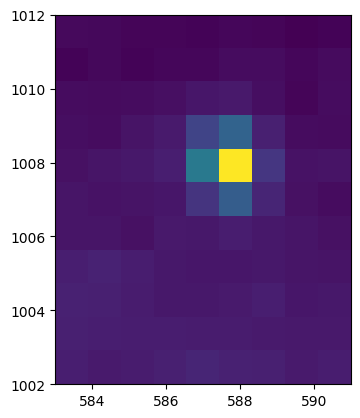

In [38]:
plt.imshow(cube[0,:,:].data[0], origin='lower', extent=[cube.pixel_col[0], cube.pixel_col[-1], cube.pixel_row[0], cube.pixel_row[-1]]) 


/Users/nthom/opt/anaconda3/envs/py3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/nthom/.lightkurve/cache. Please move all the files in the legacy directory /Users/nthom/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


<Axes: title={'center': 'Target ID: None, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

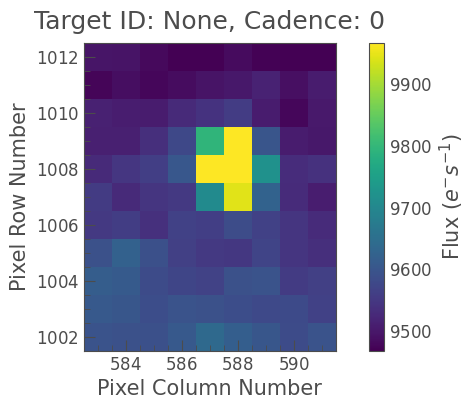

In [39]:
# TODO: I'll probably remove this, but it's a nice sanity check
import lightkurve as lk
tpf = lk.read(manifest['Local Path'][0])
tpf.plot()

In [40]:
# Get the data for the brightest pixel at location (row 6, column 5) for every time step
# Note this now becomes a DataSeries, which is equivalent to a 1-dimensional lightcurve
cube[:,6,5] 

📉 DataSeries (3450,)
time_index  time          timecorr 
0           2.459526e+06  -0.003259    10405.174805
1           2.459526e+06  -0.003258    10582.315430
2           2.459526e+06  -0.003257    10765.145508
3           2.459526e+06  -0.003257    10921.556641
4           2.459526e+06  -0.003256    11029.963867
                                           ...     
3445        2.459551e+06  -0.000952     1877.079590
3446        2.459551e+06  -0.000951     1875.521240
3447        2.459551e+06  -0.000950     1877.299072
3448        2.459551e+06  -0.000950     1872.148804
3449        2.459551e+06  -0.000949     1873.886963
Length: 3450, dtype: float64

In [41]:
# Get the first 10 time steps for the pixels containing the target star
cube[0:10, 4:9, 3:8] # Remember, this is [time, row, column]

📘 DataCube (10, 5, 5), Uncertainty: True

## binning

Often you may want to bin the data. For example, you may want to bin in the time dimension to reduce the noise to bring out features in the data or bin in the spatial dimension to visualize what your data at a lower resolution. The DataCube object makes this easy. 

In [42]:
# Bin together every 5 time steps. By default, this provides sum of the 5 images for each pixel 
# TODO: did Dan get the median/mean, etc options working for this?
cube.downsample(nframes=5, level="time")

📘 DataCube (687, 11, 9), Uncertainty: True

## Other Properties

DataCube objects have other properties you can access directly. These include col, row, and uncertainty. Note col and row are the same for all images in the stack, so they are 2D arrays. However, the uncertainties match the dimensions of the data. 

In [43]:
cube.pixel_col, cube.pixel_row, cube.uncertainty


(array([583, 584, 585, 586, 587, 588, 589, 590, 591, 583, 584, 585, 586,
        587, 588, 589, 590, 591, 583, 584, 585, 586, 587, 588, 589, 590,
        591, 583, 584, 585, 586, 587, 588, 589, 590, 591, 583, 584, 585,
        586, 587, 588, 589, 590, 591, 583, 584, 585, 586, 587, 588, 589,
        590, 591, 583, 584, 585, 586, 587, 588, 589, 590, 591, 583, 584,
        585, 586, 587, 588, 589, 590, 591, 583, 584, 585, 586, 587, 588,
        589, 590, 591, 583, 584, 585, 586, 587, 588, 589, 590, 591, 583,
        584, 585, 586, 587, 588, 589, 590, 591]),
 array([1002, 1002, 1002, 1002, 1002, 1002, 1002, 1002, 1002, 1003, 1003,
        1003, 1003, 1003, 1003, 1003, 1003, 1003, 1004, 1004, 1004, 1004,
        1004, 1004, 1004, 1004, 1004, 1005, 1005, 1005, 1005, 1005, 1005,
        1005, 1005, 1005, 1006, 1006, 1006, 1006, 1006, 1006, 1006, 1006,
        1006, 1007, 1007, 1007, 1007, 1007, 1007, 1007, 1007, 1007, 1008,
        1008, 1008, 1008, 1008, 1008, 1008, 1008, 1008, 1009, 1009, 1

You can also perform math operations on the DataCube. For example, we could create a 2D image containing the median data for each pixel. Note this returns the median data as well as the associated uncertainties

In [44]:
cube.mean(axis=0) 

(array([[ 441.70915702,  441.90164949,  442.74762009,  443.30751563,
          448.73209167,  447.50011029,  445.85401936,  446.03078338,
          445.97807838],
        [ 442.9823173 ,  445.34149042,  445.21798723,  443.34600693,
          444.92858795,  446.72741703,  445.51862133,  444.96006744,
          447.29034712],
        [ 449.10543462,  474.56729522,  469.81612059,  445.88005932,
          444.63421032,  446.63625166,  445.3120578 ,  445.60571569,
          446.5987413 ],
        [ 453.32641371,  511.95360876,  486.00005065,  448.07536592,
          445.7117158 ,  447.0070988 ,  445.11378039,  444.7217063 ,
          444.58961925],
        [ 456.06697208,  462.32794843,  454.43630254,  450.81216112,
          461.62786976,  474.29533546,  458.1841948 ,  445.43414266,
          443.75498544],
        [ 452.08551252,  448.9351441 ,  451.87270265,  470.72271937,
          612.44046881,  826.30973132,  555.66185435,  452.3375759 ,
          443.79824917],
        [ 445.97220238

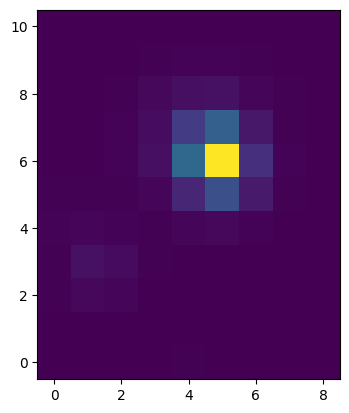

In [45]:
plt.imshow(cube.mean(axis=0)[0], origin='lower')
plt.show()

In [46]:
# by default, axis=None, which gives the mean of all data in all dimensions
cube.mean(axis=None)

(490.68355577574135, Uncertainty(0.00184842))

### 3.1 BitwiseCube

As mentioned in the introduction, BitwiseCube was developed to handle the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) and [Kepler/K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf) quality masks. The quality flags are stored in a bitwise operation so that we can easily disentangle all flags attributed to a given time step. When 'adding' bitwise flags, for example when downsampling, we want BitwiseCubes to keep track of all flags that are triggered over the time step. Let's see how this looks in practice below. 

In [60]:
quality_flags = lcf[1].data['QUALITY']
print(quality_flags)
print(np.unique(quality_flags))

[128 128 128 ...   0   0   0]
[    0    32   128   164 16384 16416 16512]


We can see above that a number of quality flags can be found in this TPF. These include
- 0: No quality flag
- 32: Reaction Wheel desaturation Event
- 128: Manual Exclude. The cadence was excluded because of an anomaly
- 164: (128+32+4) Manual Exclude. The cadence was excluded because of an anomaly + Reaction Wheel desaturation Event + Spacecraft is in Coarse Point
- 16384: Bad Calibration Exclude (pipeline >= spoc-4.0.14)
- 16416: (16384 + 32) Bad Calibration Exclude + Reaction Wheel desaturation Event
- 16512: (16384 + 128) Bad Calibration Exclude + Manual Exclude due to an anomaly.

In [63]:
bitwise = lkdata.BitwiseSeries(data=quality_flags,
                       time_indices={'time':time + 2457000},
                          )
bitwise

📗 BitwiseSeries (3450,)
time_index  time        
0           2.459526e+06    128
1           2.459526e+06    128
2           2.459526e+06    128
3           2.459526e+06    128
4           2.459526e+06    128
                           ... 
3445        2.459551e+06      0
3446        2.459551e+06      0
3447        2.459551e+06      0
3448        2.459551e+06      0
3449        2.459551e+06      0
Length: 3450, dtype: int64

In [65]:
# If we 'sum' the bitwise set, we get a list of all individual flags that are found in the BitwiseSet
bitwise.sum()

BitSet {4, 32, 128, 16384}

In [69]:
# downsampling a BitwiseSeries gives the sum of all individual flags found in each bin. 
bitwise.downsample(nframes=5)

📗 BitwiseSeries (687,)
mid_index  indices                     time        
8.0        [ 6  7  8  9 10]            2.459526e+06      128
13.0       [11 12 13 14 15]            2.459526e+06    16512
18.0       [16 17 18 19 20]            2.459526e+06    16512
23.0       [21 22 23 24 25]            2.459526e+06    16512
28.0       [26 27 28 29 30]            2.459526e+06    16512
                                                       ...  
3425.0     [3423 3424 3425 3426 3427]  2.459550e+06        0
3430.0     [3428 3429 3430 3431 3432]  2.459550e+06        0
3435.0     [3433 3434 3435 3436 3437]  2.459551e+06        0
3440.0     [3438 3439 3440 3441 3442]  2.459551e+06        0
3445.0     [3443 3444 3445 3446 3447]  2.459551e+06        0
Length: 687, dtype: int64

# 4 - Putting it all together with DataSet

Now that we understand the different classes in lkdata, let's try to put it all together. For example, a DataSeries can only contain one data array, but what if we want to tie multiple bits of data together? For example, we may want to track the Simple Aperture Photometry (SAP) as well as the Pre-search Data Conditioning-SAP (PDCSAP) so that if we manipulate the data (by downsampling or slicing) the operation is performed on both DataSets with one command. DataSets allow us to do this. They are also flexible enough to handle any of the different types of data products (DataSeries/Frame/Cube, BoolSeries/Frame/Cube, BitwiseSeries/Frame/Cube). Let's use our K2-18 data from Section 3 as an example. 

In [71]:
# TODO: DataSet docstring is not clear with how DataSet init works. 
# TODO: how do aperture get handled? 
ds = lkdata.DataSet({'tpf':cube, 'quality':bitwise})
ds


        Data Products:
        {'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True, 'quality': 📗 BitwiseSeries (3450,)
time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06    128
1           2.459526e+06  -0.003258  2.459526e+06    128
2           2.459526e+06  -0.003257  2.459526e+06    128
3           2.459526e+06  -0.003257  2.459526e+06    128
4           2.459526e+06  -0.003256  2.459526e+06    128
                                                    ... 
3445        2.459551e+06  -0.000952  2.459551e+06      0
3446        2.459551e+06  -0.000951  2.459551e+06      0
3447        2.459551e+06  -0.000950  2.459551e+06      0
3448        2.459551e+06  -0.000950  2.459551e+06      0
3449        2.459551e+06  -0.000949  2.459551e+06      0
Length: 3450, dtype: int64}
        Bool Products:
        {}
        Bitwise Products:
        {}
        Properties:
        []

In [72]:

lkdata.DataSet({'tpf':cube}, {'quality':bitwise})


        Data Products:
        {'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
        Bool Products:
        {'quality': 📗 BitwiseSeries (3450,)
time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06    128
1           2.459526e+06  -0.003258  2.459526e+06    128
2           2.459526e+06  -0.003257  2.459526e+06    128
3           2.459526e+06  -0.003257  2.459526e+06    128
4           2.459526e+06  -0.003256  2.459526e+06    128
                                                    ... 
3445        2.459551e+06  -0.000952  2.459551e+06      0
3446        2.459551e+06  -0.000951  2.459551e+06      0
3447        2.459551e+06  -0.000950  2.459551e+06      0
3448        2.459551e+06  -0.000950  2.459551e+06      0
3449        2.459551e+06  -0.000949  2.459551e+06      0
Length: 3450, dtype: int64}
        Bitwise Products:
        {}
        Properties:
        []

In [73]:
lkdata.DataSet(data_products={'tpf':cube}, bitwise_products={'quality':bitwise})


        Data Products:
        {'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
        Bool Products:
        {}
        Bitwise Products:
        {'quality': 📗 BitwiseSeries (3450,)
time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06    128
1           2.459526e+06  -0.003258  2.459526e+06    128
2           2.459526e+06  -0.003257  2.459526e+06    128
3           2.459526e+06  -0.003257  2.459526e+06    128
4           2.459526e+06  -0.003256  2.459526e+06    128
                                                    ... 
3445        2.459551e+06  -0.000952  2.459551e+06      0
3446        2.459551e+06  -0.000951  2.459551e+06      0
3447        2.459551e+06  -0.000950  2.459551e+06      0
3448        2.459551e+06  -0.000950  2.459551e+06      0
3449        2.459551e+06  -0.000949  2.459551e+06      0
Length: 3450, dtype: int64}
        Properties:
        []

In [79]:
cube = lkdata.DataSet(data_products={'tpf':cube}, 
               bool_products={'quality_flag':bitwise.values >0},
               bitwise_products={'quality':bitwise},
               target='K2-18')
cube


        Data Products:
        {'tpf': 📘 DataCube (3450, 11, 9), Uncertainty: True}
        Bool Products:
        {'quality_flag': ⚫️⚪️ BoolSeries (3450,)
time_index  time          timecorr   time_       
0           2.459526e+06  -0.003259  2.459526e+06     True
1           2.459526e+06  -0.003258  2.459526e+06     True
2           2.459526e+06  -0.003257  2.459526e+06     True
3           2.459526e+06  -0.003257  2.459526e+06     True
4           2.459526e+06  -0.003256  2.459526e+06     True
                                                     ...  
3445        2.459551e+06  -0.000952  2.459551e+06    False
3446        2.459551e+06  -0.000951  2.459551e+06    False
3447        2.459551e+06  -0.000950  2.459551e+06    False
3448        2.459551e+06  -0.000950  2.459551e+06    False
3449        2.459551e+06  -0.000949  2.459551e+06    False
Length: 3450, dtype: bool}
        Bitwise Products:
        {'quality': 📗 BitwiseSeries (3450,)
time_index  time          timecorr   time_     

In [80]:
# TODO: I expect there to be a describe_cube function like there is for the other products
cube.describe_set()

AttributeError: 'DataSet' object has no attribute 'describe_cube'

In [81]:
cube.target

'K2-18'

In [82]:
cube.downsample(2)


        Data Products:
        {'tpf': 📘 DataCube (1722, 11, 9), Uncertainty: False}
        Bool Products:
        {'quality_flag': ⚫️⚪️ BoolSeries (1722,)
mid_index  indices      time          timecorr   time_       
3.5        [3 4]        2.459526e+06  -0.003257  2.459526e+06     True
5.5        [5 6]        2.459526e+06  -0.003256  2.459526e+06     True
7.5        [7 8]        2.459526e+06  -0.003255  2.459526e+06     True
9.5        [ 9 10]      2.459526e+06  -0.003254  2.459526e+06     True
11.5       [11 12]      2.459526e+06  -0.003253  2.459526e+06     True
                                                                 ...  
3439.5     [3439 3440]  2.459551e+06  -0.000955  2.459551e+06    False
3441.5     [3441 3442]  2.459551e+06  -0.000954  2.459551e+06    False
3443.5     [3443 3444]  2.459551e+06  -0.000953  2.459551e+06    False
3445.5     [3445 3446]  2.459551e+06  -0.000951  2.459551e+06    False
3447.5     [3447 3448]  2.459551e+06  -0.000950  2.459551e+06    False

In [83]:
# TODO: I expect cubes to be able to handle a spatial downsample
cube.spatial_downsample(2)

AttributeError: 'DataSet' object has no attribute 'spatial_downsample'